In [2]:
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
import json

### YQFWKNFQ_8AAs MPS run
- 50k shots
- 800 COBYLA iterations

In [5]:
# Load the data
res_dir = "../res/fcc_hw/YQFWKNFQ_2025-01-31_aer_simulator_matrix_product_state/"
metadata_path = res_dir + "metadata.json"
opt_res_path = res_dir + "opt_results.json"

with open(metadata_path, "r") as f:
    metadata = json.load(f)
with open(opt_res_path, "r") as f:
    opt_res = json.load(f)

In [7]:
for key in opt_res:
    print(key)

final_cost
opt_params
cost_trajectory
top_solutions


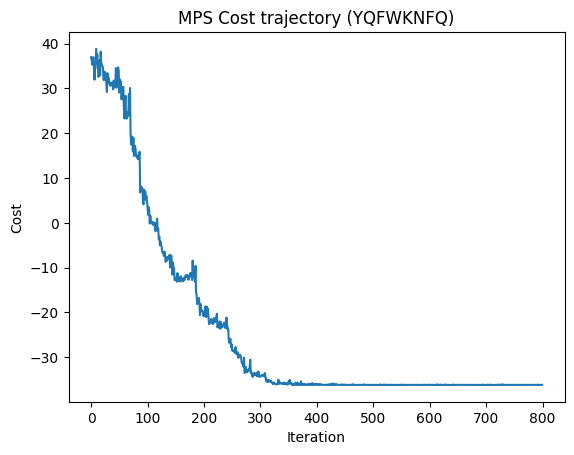

In [9]:
# Plot cost trajectory
plt.figure()
plt.plot(opt_res["cost_trajectory"])
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("MPS Cost trajectory (YQFWKNFQ)")
plt.show()

In [10]:
opt_res["top_solutions"][:10]

[['1011011101110000000011110111110011101001110', -36.168256937560024],
 ['1111011101110000000011110111110011101001110', -34.878256937560025],
 ['1011011101010000000011110111110011101001110', -34.62825693756002],
 ['0011011101110000000011110111110011101001110', -34.45825693756002],
 ['1111011101010000000011110111110011101001110', -33.33825693756002],
 ['1011011101110001000011110111110011101001110', -33.19825693756002],
 ['0111011101110000000011110111110011101001110', -33.168256937560024],
 ['1011001101110000000011110111110011101001110', -33.09825693756002],
 ['1010011101110000000011110111110011101001110', -33.058256937560024],
 ['0011011101010000000011110111110011101001110', -32.91825693756002]]

In [11]:
# Extract classical results
cs_dir = "../classical_search/cs_res/"

def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2", 
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b"
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list[str]:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append(relabel_turns(turns))
    return top_cls_turns

In [13]:
def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x", # unphysical
        "0010": "x", # unphysical
        "1101": "x", # unphysical
        "1110": "x", # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]

In [17]:
# Get top 100 solutions from MPS results
top_mps_bitstrings = [sol[0] for sol in opt_res["top_solutions"][:100]]
top_mps_turns = [convert_bitstring_to_turns(soln, metadata["main_seq"]) for soln in top_mps_bitstrings]

# Get top 100 solutions from classical search results
top_cls_solns = load_top_cls_solns(f"{len(metadata['main_seq'])}AA_{metadata['main_seq']}_topobj.txt")[:100]

In [18]:
# Check overlapping ratio
overlap_soln_ratio = len(set(top_mps_turns).intersection(set(top_cls_solns))) / 100
print(f"Overlap ratio: {overlap_soln_ratio}")

Overlap ratio: 0.0
